<a href="https://colab.research.google.com/github/CaseyWongWc/CS4990-GenAI/blob/main/MiniProject1/CS4990_MiniProject1_NADE_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS 4990 Mini-Project 1: NADE on MNIST
**Casey Wong** | Spring 2026 | Professor Kosaraju

---

## Overview
This notebook implements **Neural Autoregressive Distribution Estimation (NADE)** — an autoregressive generative model — on the MNIST handwritten digit dataset.

**What NADE does:** Models the joint probability of an image by decomposing it into a product of conditionals using the chain rule:

$$p(\mathbf{x}) = \prod_{i=1}^{D} p(x_i \mid x_1, \ldots, x_{i-1})$$

Each pixel's probability is conditioned on all previous pixels, computed via a shared neural network with **weight tying** for parameter efficiency.

**Key concepts demonstrated:**
- Autoregressive factorization (chain rule)
- Weight-tied hidden layers
- Binary Cross-Entropy as Negative Log-Likelihood
- Sequential (pixel-by-pixel) sampling
- Digit-conditioned generation and style transfer

## 1. Setup and Imports

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from torchvision import datasets
import numpy as np
from tqdm import tqdm
import time

# Use GPU if available (Colab: Runtime > Change runtime type > T4 GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


## 2. Load and Prepare MNIST Data
We binarize the images (threshold at 0.5) since NADE models binary distributions.
We train on all 10 digit classes to demonstrate full generative capability.

In [14]:
# Transform: convert to tensor, flatten to 784-dim vector, binarize
transform = transforms.Compose([
    transforms.ToTensor(),
    lambda x: (x > 0.5).float(),  # Binarize for Bernoulli NADE
    lambda x: x.view(-1)           # Flatten 28x28 -> 784
])

# Download MNIST
mnist_train = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
mnist_test = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

# Create data loaders
train_loader = torch.utils.data.DataLoader(mnist_train, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(mnist_test, batch_size=64, shuffle=False)

# Also create per-digit datasets for conditional generation later
digit_data = {}
for digit in range(10):
    digit_data[digit] = torch.stack([img for img, label in mnist_train if label == digit])
    print(f'Digit {digit}: {len(digit_data[digit])} samples')

print(f'\nTotal training samples: {len(mnist_train)}')
print(f'Input dimension: 784 (28x28 pixels, binarized)')

Digit 0: 5923 samples
Digit 1: 6742 samples
Digit 2: 5958 samples
Digit 3: 6131 samples
Digit 4: 5842 samples
Digit 5: 5421 samples
Digit 6: 5918 samples
Digit 7: 6265 samples
Digit 8: 5851 samples
Digit 9: 5949 samples

Total training samples: 60000
Input dimension: 784 (28x28 pixels, binarized)


## 3. Visualize Sample Data
Let's see what the binarized MNIST digits look like.

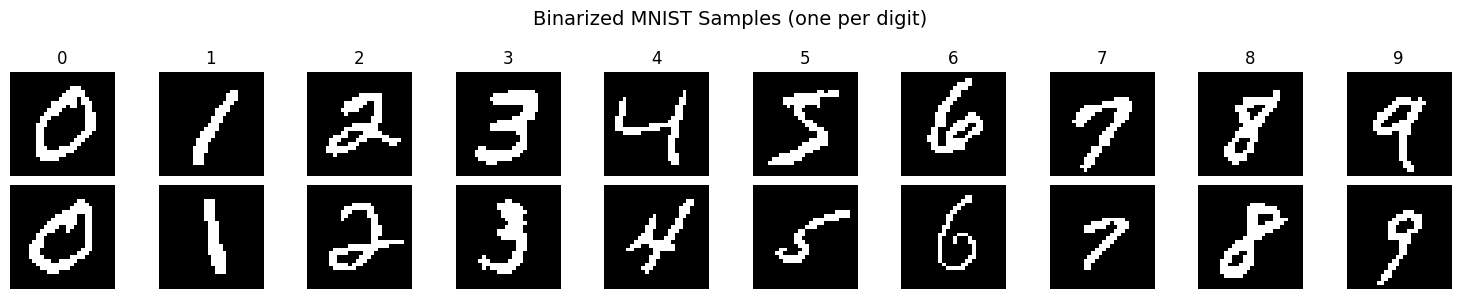

In [15]:
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
fig.suptitle('Binarized MNIST Samples (one per digit)', fontsize=14)

for digit in range(10):
    # Show first example of each digit
    img = digit_data[digit][0].view(28, 28).numpy()
    axes[0, digit].imshow(img, cmap='gray')
    axes[0, digit].set_title(str(digit), fontsize=12)
    axes[0, digit].axis('off')

    # Show second example
    img2 = digit_data[digit][1].view(28, 28).numpy()
    axes[1, digit].imshow(img2, cmap='gray')
    axes[1, digit].axis('off')

plt.tight_layout()
plt.show()

## 4. NADE Model Architecture

The core idea of NADE:
- For each pixel $x_i$, compute a hidden representation from all previous pixels $x_{1:i-1}$
- Use shared weight matrix $\mathbf{W}$ (weight tying) — this is what makes NADE efficient
- The hidden state builds incrementally: $\mathbf{h}_i = \sigma(\mathbf{W}_{:, <i} \cdot \mathbf{x}_{<i} + \mathbf{b}_h)$
- Output probability: $p(x_i = 1 \mid \mathbf{x}_{<i}) = \sigma(\mathbf{V}_i \cdot \mathbf{h}_i + b_{x_i})$

Below we implement two versions:
1. **Simplified NADE** — matches Professor Kosaraju's class example (full-context forward pass)
2. **Proper Autoregressive NADE** — true sequential conditioning for generation

In [16]:
class NADE(nn.Module):
    """
    Neural Autoregressive Distribution Estimator (NADE)

    Implements the NADE model from Larochelle & Murray (2011).

    Architecture:
        - Shared weight matrix W (input_dim x hidden_dim) with weight tying
        - Output weight matrix V (hidden_dim x input_dim)
        - Sigmoid activations for both hidden layer and output probabilities

    Key insight: The forward pass uses a cumulative-sum trick to efficiently
    compute all D conditional distributions P(x_i | x_<i) in one pass,
    while properly enforcing the autoregressive property (pixel i only
    sees pixels 1 through i-1, never itself or future pixels).
    """

    def __init__(self, input_dim, hidden_dim):
        super(NADE, self).__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim

        # Shared weight matrix W (weight tying across all conditionals)
        self.W = nn.Linear(input_dim, hidden_dim, bias=False)

        # Output weights V (one row per pixel dimension)
        self.V = nn.Linear(hidden_dim, input_dim, bias=False)

        # Bias terms
        self.b_h = nn.Parameter(torch.zeros(hidden_dim))   # Hidden bias
        self.b_x = nn.Parameter(torch.zeros(input_dim))    # Output bias

    def forward(self, x):
        """
        Efficient autoregressive forward pass using cumulative sums.

        For each pixel i, we need:
            a_i = b_h + sum_{j < i} W[:, j] * x_j
            h_i = sigmoid(a_i)
            p_i = sigmoid(V[i, :] . h_i + b_x[i])

        We compute all a_i simultaneously using cumsum with a right-shift:
            contributions[:, :, j] = W[:, j] * x[:, j]
            cumulative = cumsum(contributions, dim=-1)
            a[:, :, i] = cumulative[:, :, i-1] + b_h   (shifted so pixel i excludes itself)

        Args:
            x: Input tensor (batch_size, input_dim)
        Returns:
            p_x: Predicted probabilities (batch_size, input_dim)
        """
        batch_size = x.shape[0]
        W_weight = self.W.weight  # (hidden_dim, input_dim)
        V_weight = self.V.weight  # (input_dim, hidden_dim)

        # Compute per-pixel contributions to hidden state: W[:,j] * x[:,j]
        # x: (B, D) -> (B, 1, D),  W: (H, D) -> (1, H, D)
        contributions = x.unsqueeze(1) * W_weight.unsqueeze(0)  # (B, H, D)

        # Cumulative sum along pixel dimension
        cumsum = torch.cumsum(contributions, dim=2)  # (B, H, D)

        # Shift right: a_i should be sum of contributions for j < i (not including i)
        # a_0 = b_h (no previous pixels), a_1 = b_h + W[:,0]*x_0, etc.
        a = torch.zeros_like(cumsum)
        a[:, :, 1:] = cumsum[:, :, :-1]  # shift right by 1
        a = a + self.b_h.unsqueeze(0).unsqueeze(2)  # add bias: (1, H, 1)

        # Hidden states for all pixels
        h = torch.sigmoid(a)  # (B, H, D)

        # Output probabilities: for pixel i, p_i = sigmoid(V[i,:] . h[:,:,i] + b_x[i])
        # V_weight: (D, H), h: (B, H, D)
        # We need: for each i, sum over H of V[i, h] * h[b, h, i]
        # V_weight.T: (H, D), element-wise with h: (B, H, D), sum over H -> (B, D)
        logits = (V_weight.T.unsqueeze(0) * h).sum(dim=1) + self.b_x  # (B, D)

        p_x = torch.sigmoid(logits)  # (B, D)

        return p_x

    def generate(self, num_samples=1, device='cpu'):
        """
        Autoregressive generation — samples one pixel at a time.

        For each pixel i:
          1. h_i = sigmoid(a_i)  where a_i accumulates W[:,j]*x_j for j < i
          2. p_i = sigmoid(V[i, :] . h_i + b_x[i])
          3. x_i ~ Bernoulli(p_i)

        Uses an accumulator for efficient O(D*H) total compute.
        """
        self.eval()
        W_weight = self.W.weight.data    # shape: (hidden_dim, input_dim)
        V_weight = self.V.weight.data    # shape: (input_dim, hidden_dim)

        with torch.no_grad():
            samples = torch.zeros(num_samples, self.input_dim).to(device)

            # Accumulator: starts with just bias (no input pixels yet)
            a = self.b_h.unsqueeze(0).expand(num_samples, -1).clone()  # (batch, hidden)

            for i in range(self.input_dim):
                # Hidden state for pixel i
                h_i = torch.sigmoid(a)                          # (batch, hidden)

                # Probability of pixel i being 1
                p_i = torch.sigmoid(V_weight[i, :] @ h_i.T + self.b_x[i])  # (batch,)

                # Sample pixel i
                samples[:, i] = torch.bernoulli(p_i)

                # Update accumulator: add W[:, i] * x_i for next iteration
                a = a + samples[:, i].unsqueeze(1) * W_weight[:, i].unsqueeze(0)

        self.train()
        return samples


# Instantiate model
input_dim = 784   # 28 x 28 flattened
hidden_dim = 500  # Hidden units (500 is standard for NADE on MNIST)

model = NADE(input_dim, hidden_dim).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f'NADE Architecture:')
print(f'  Input dim:  {input_dim}')
print(f'  Hidden dim: {hidden_dim}')
print(f'  Total parameters: {total_params:,}')
print(f'  Device: {device}')

NADE Architecture:
  Input dim:  784
  Hidden dim: 500
  Total parameters: 785,284
  Device: cuda


## 5. Training

We use **Binary Cross-Entropy (BCE)** loss, which is equivalent to the **Negative Log-Likelihood** for Bernoulli distributions:

$$\mathcal{L} = -\frac{1}{N}\sum_{n=1}^{N}\sum_{i=1}^{D} \left[ x_i^{(n)} \log p_i^{(n)} + (1 - x_i^{(n)}) \log(1 - p_i^{(n)}) \right]$$

This is the standard training objective for autoregressive models.

In [17]:
# Training hyperparameters
num_epochs = 20
learning_rate = 0.001

optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.BCELoss()  # Binary Cross-Entropy = Negative Log-Likelihood

# Training loop
train_losses = []
test_losses = []

print('Training NADE on MNIST...')
print(f'Epochs: {num_epochs} | LR: {learning_rate} | Batch size: 64')
print('-' * 50)

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    num_batches = 0

    for x, _ in train_loader:  # Ignore labels (unsupervised)
        x = x.to(device)

        optimizer.zero_grad()
        x_hat = model(x)               # Predicted probabilities
        loss = criterion(x_hat, x)      # BCE / NLL loss
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        num_batches += 1

    avg_train_loss = epoch_loss / num_batches
    train_losses.append(avg_train_loss)

    # Evaluate on test set
    model.eval()
    test_loss = 0
    test_batches = 0
    with torch.no_grad():
        for x, _ in test_loader:
            x = x.to(device)
            x_hat = model(x)
            loss = criterion(x_hat, x)
            test_loss += loss.item()
            test_batches += 1

    avg_test_loss = test_loss / test_batches
    test_losses.append(avg_test_loss)

    print(f'Epoch {epoch+1:2d}/{num_epochs} | '
          f'Train Loss: {avg_train_loss:.4f} | '
          f'Test Loss: {avg_test_loss:.4f}')

print('-' * 50)
print(f'Final Train Loss: {train_losses[-1]:.4f}')
print(f'Final Test Loss:  {test_losses[-1]:.4f}')

Training NADE on MNIST...
Epochs: 20 | LR: 0.001 | Batch size: 64
--------------------------------------------------
Epoch  1/20 | Train Loss: 0.1718 | Test Loss: 0.1267
Epoch  2/20 | Train Loss: 0.1170 | Test Loss: 0.1079
Epoch  3/20 | Train Loss: 0.1047 | Test Loss: 0.1004
Epoch  4/20 | Train Loss: 0.0987 | Test Loss: 0.0962
Epoch  5/20 | Train Loss: 0.0950 | Test Loss: 0.0936
Epoch  6/20 | Train Loss: 0.0925 | Test Loss: 0.0918
Epoch  7/20 | Train Loss: 0.0906 | Test Loss: 0.0905
Epoch  8/20 | Train Loss: 0.0891 | Test Loss: 0.0894
Epoch  9/20 | Train Loss: 0.0879 | Test Loss: 0.0888
Epoch 10/20 | Train Loss: 0.0869 | Test Loss: 0.0880
Epoch 11/20 | Train Loss: 0.0861 | Test Loss: 0.0875
Epoch 12/20 | Train Loss: 0.0853 | Test Loss: 0.0870
Epoch 13/20 | Train Loss: 0.0847 | Test Loss: 0.0867
Epoch 14/20 | Train Loss: 0.0841 | Test Loss: 0.0865
Epoch 15/20 | Train Loss: 0.0835 | Test Loss: 0.0861
Epoch 16/20 | Train Loss: 0.0831 | Test Loss: 0.0858
Epoch 17/20 | Train Loss: 0.0826 | 

## 6. Training Curves

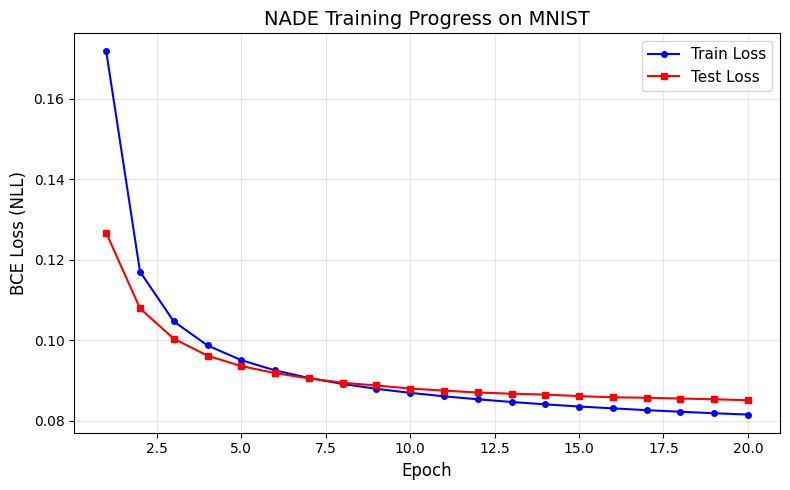

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs+1), train_losses, 'b-o', label='Train Loss', markersize=4)
plt.plot(range(1, num_epochs+1), test_losses, 'r-s', label='Test Loss', markersize=4)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('BCE Loss (NLL)', fontsize=12)
plt.title('NADE Training Progress on MNIST', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Generation: Sampling New Digits

NADE generates images **autoregressively** — one pixel at a time, left-to-right, top-to-bottom.
Each pixel $x_i$ is sampled from $\text{Bernoulli}(p_i)$ where $p_i = P(x_i=1 \mid x_1,...,x_{i-1})$.

This is the defining property of autoregressive models: **exact likelihood** and **tractable sampling**.

Generating 20 new digit images (pixel by pixel)...
Generation time: 0.1s (0.01s per image)


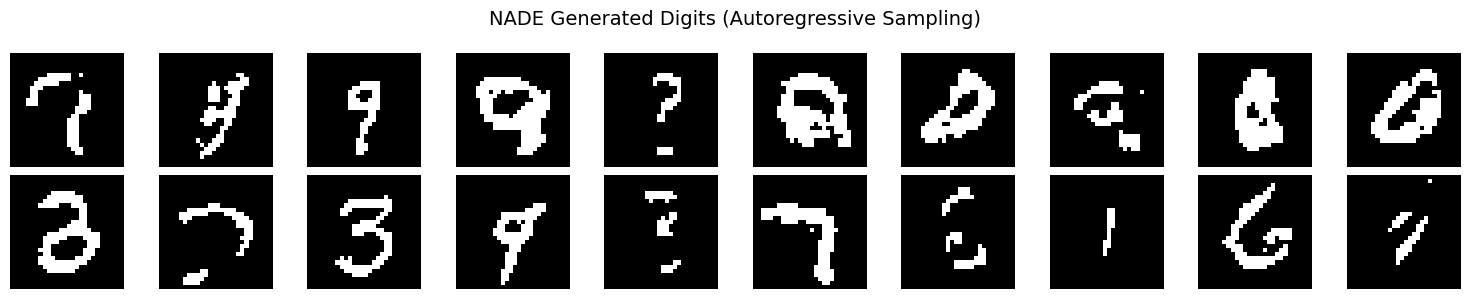

In [19]:
# Generate samples
print('Generating 20 new digit images (pixel by pixel)...')
start_time = time.time()
generated = model.generate(num_samples=20, device=device)
gen_time = time.time() - start_time
print(f'Generation time: {gen_time:.1f}s ({gen_time/20:.2f}s per image)')

# Display generated images
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
fig.suptitle('NADE Generated Digits (Autoregressive Sampling)', fontsize=14)

for i in range(20):
    row = i // 10
    col = i % 10
    img = generated[i].cpu().view(28, 28).numpy()
    axes[row, col].imshow(img, cmap='gray')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

## 8. Reconstruction Quality
Compare original test images with NADE's predicted probabilities (reconstruction).

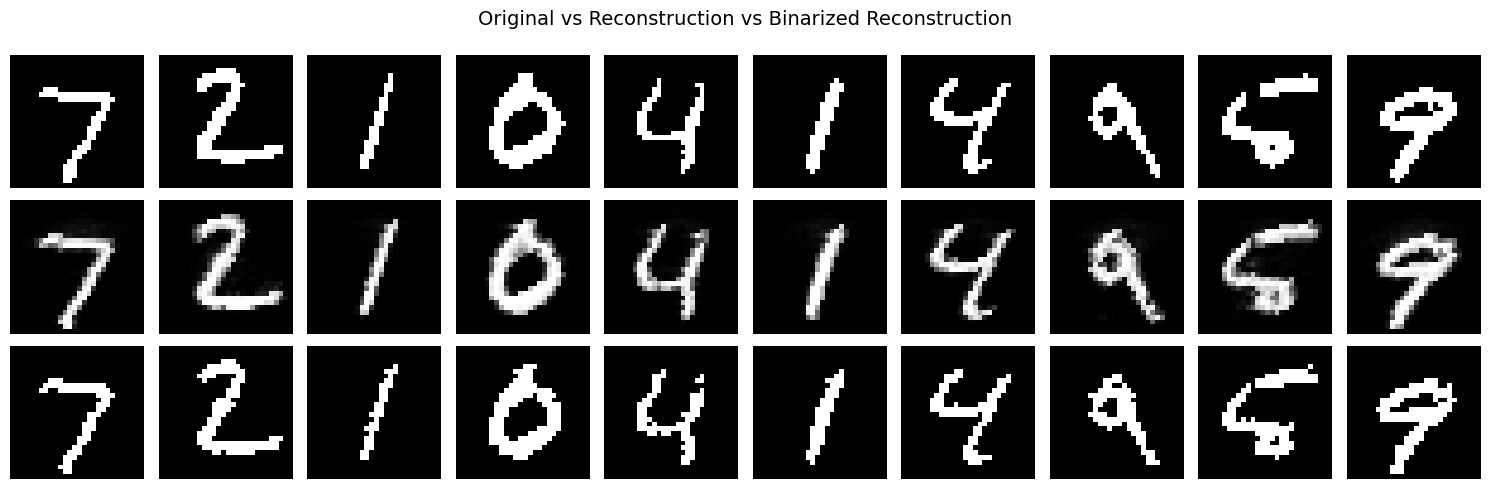

In [20]:
# Get a batch of test images
test_imgs, test_labels = next(iter(test_loader))
test_imgs = test_imgs.to(device)

# Get reconstructions
model.eval()
with torch.no_grad():
    reconstructions = model(test_imgs)

# Display originals vs reconstructions
n_show = 10
fig, axes = plt.subplots(3, n_show, figsize=(15, 5))
fig.suptitle('Original vs Reconstruction vs Binarized Reconstruction', fontsize=14)

for i in range(n_show):
    # Original
    axes[0, i].imshow(test_imgs[i].cpu().view(28, 28).numpy(), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_ylabel('Original', fontsize=11)

    # Reconstruction (probabilities)
    axes[1, i].imshow(reconstructions[i].cpu().view(28, 28).numpy(), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_ylabel('P(x_i)', fontsize=11)

    # Binarized reconstruction
    binarized = (reconstructions[i] > 0.5).float()
    axes[2, i].imshow(binarized.cpu().view(28, 28).numpy(), cmap='gray')
    axes[2, i].axis('off')
    if i == 0:
        axes[2, i].set_ylabel('Binarized', fontsize=11)

plt.tight_layout()
plt.show()

## 9. Digit-Specific Generation
Train separate NADE models on specific digit pairs and demonstrate generation from each.

Training digit-specific NADE models...
  Digit 4: trained 15 epochs, final loss = 0.0946
  Digit 5: trained 15 epochs, final loss = 0.1068

Generating samples...


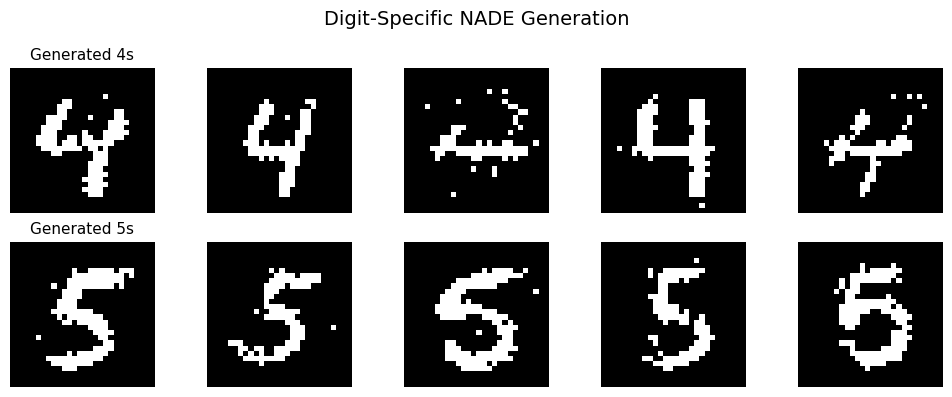

In [21]:
def train_digit_nade(digit_class, epochs=15):
    """Train a NADE model on a specific digit class."""
    data = digit_data[digit_class].to(device)
    loader = torch.utils.data.DataLoader(data, batch_size=64, shuffle=True)

    digit_model = NADE(784, 500).to(device)
    opt = optim.Adam(digit_model.parameters(), lr=0.001)
    loss_fn = nn.BCELoss()

    for epoch in range(epochs):
        total_loss = 0
        for x in loader:
            x = x.view(-1, 784)
            opt.zero_grad()
            x_hat = digit_model(x)
            loss = loss_fn(x_hat, x)
            loss.backward()
            opt.step()
            total_loss += loss.item()

    final_loss = total_loss / len(loader)
    print(f'  Digit {digit_class}: trained {epochs} epochs, final loss = {final_loss:.4f}')
    return digit_model

# Train on digits 4 and 5 (matching professor's example)
print('Training digit-specific NADE models...')
model_4 = train_digit_nade(4)
model_5 = train_digit_nade(5)

# Generate from each
print('\nGenerating samples...')
gen_4 = model_4.generate(num_samples=5, device=device)
gen_5 = model_5.generate(num_samples=5, device=device)

# Display
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
fig.suptitle('Digit-Specific NADE Generation', fontsize=14)

for i in range(5):
    axes[0, i].imshow(gen_4[i].cpu().view(28, 28).numpy(), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Generated 4s', fontsize=11)

    axes[1, i].imshow(gen_5[i].cpu().view(28, 28).numpy(), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Generated 5s', fontsize=11)

plt.tight_layout()
plt.show()

## 10. Style Transfer (Digit Blending)

Following the class example: use NADE-generated images and blend style information
from one digit class onto another. This demonstrates that NADE captures meaningful
spatial structure that can be manipulated.

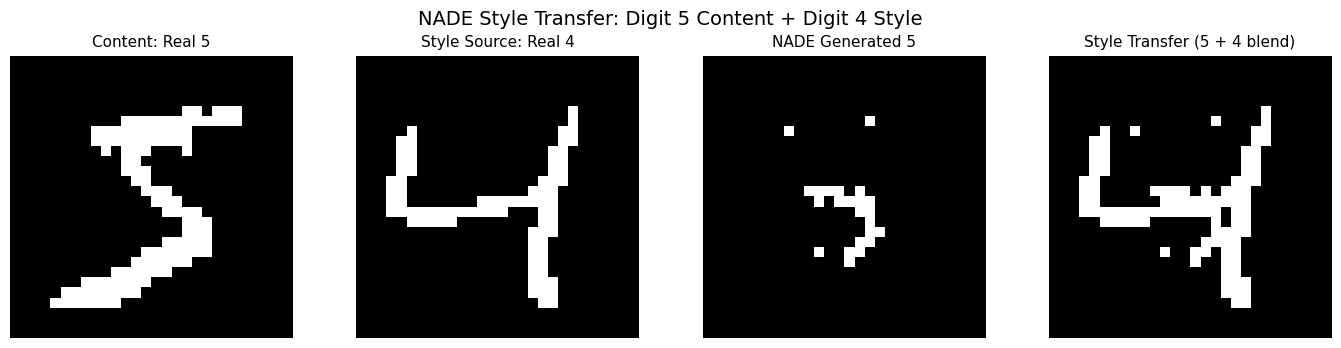

In [22]:
# Use the digit-specific models
# Content = digit 5 (what we want to generate)
# Style = digit 4 (structural influence)

content_digit = digit_data[5][0].to(device).view(1, 784)  # Real digit 5
style_digit = digit_data[4][0].to(device).view(1, 784)    # Real digit 4

# Generate a new 5 using NADE
generated_5 = model_5.generate(num_samples=1, device=device)

# Style transfer: overlay style (digit 4) structure onto generated 5
with torch.no_grad():
    blended = generated_5.clone()
    style_mask = style_digit > 0.5  # Where digit 4 has active pixels
    blended[style_mask] = style_digit[style_mask]  # Apply style

# Display results
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
titles = ['Content: Real 5', 'Style Source: Real 4',
          'NADE Generated 5', 'Style Transfer (5 + 4 blend)']
images = [content_digit, style_digit, generated_5, blended]

for i, (img, title) in enumerate(zip(images, titles)):
    axes[i].imshow(img.cpu().view(28, 28).numpy(), cmap='gray')
    axes[i].set_title(title, fontsize=11)
    axes[i].axis('off')

plt.suptitle('NADE Style Transfer: Digit 5 Content + Digit 4 Style', fontsize=14)
plt.tight_layout()
plt.show()

## 11. Analysis: NADE Strengths and Limitations

### Strengths of NADE:
- **Exact log-likelihood** computation (unlike GANs/VAEs)
- **No mode collapse** (unlike GANs)
- **Weight tying** makes it parameter-efficient
- **Simple architecture** — easy to implement and understand

### Limitations:
- **Slow generation** — must sample one pixel at a time (784 sequential steps per image)
- **Fixed ordering** — assumes left-to-right, top-to-bottom pixel ordering
- **Binary only** (vanilla NADE) — RNADE extends to continuous distributions
- **Blurry outputs** compared to more modern methods (GANs, diffusion models)

### Where NADE fits in the ARM evolution:
1. CPT → too many parameters
2. FVSBN → logistic regression (too simple)
3. **NADE → neural networks + weight tying (this project)**
4. MADE → masked autoencoders for parallel training
5. PixelRNN/PixelCNN → spatial awareness for images
6. Transformers/GPT → attention-based, state of the art

## 12. Generation Speed Comparison
Demonstrate the key tradeoff of autoregressive models: exact likelihood vs. slow sampling.

In [23]:
# Time generation for different sample counts
sample_counts = [1, 5, 10]
print('Generation Speed Benchmark:')
print('-' * 40)

for n in sample_counts:
    start = time.time()
    _ = model.generate(num_samples=n, device=device)
    elapsed = time.time() - start
    print(f'  {n:2d} samples: {elapsed:.2f}s  ({elapsed/n:.2f}s per image)')

print('-' * 40)
print(f'Each image requires {input_dim} sequential steps through the hidden state.')
print('This is the fundamental speed limitation of autoregressive models.')
print('Solutions: MADE (parallel training), PixelCNN (spatial convolutions).')

Generation Speed Benchmark:
----------------------------------------
   1 samples: 0.11s  (0.11s per image)
   5 samples: 0.11s  (0.02s per image)
  10 samples: 0.11s  (0.01s per image)
----------------------------------------
Each image requires 784 sequential steps through the hidden state.
This is the fundamental speed limitation of autoregressive models.
Solutions: MADE (parallel training), PixelCNN (spatial convolutions).


## 13. Log-Likelihood Evaluation
Compute the average negative log-likelihood on the test set — this is the primary metric for evaluating density estimators.

In [24]:
model.eval()
total_nll = 0
total_samples = 0

with torch.no_grad():
    for x, _ in test_loader:
        x = x.to(device)
        p_x = model(x)

        # Per-sample NLL (sum over pixels, not mean)
        nll = F.binary_cross_entropy(p_x, x, reduction='sum')
        total_nll += nll.item()
        total_samples += x.size(0)

avg_nll = total_nll / total_samples
avg_nll_per_pixel = avg_nll / input_dim

print(f'Test Set Evaluation:')
print(f'  Average NLL per image: {avg_nll:.2f} nats')
print(f'  Average NLL per pixel: {avg_nll_per_pixel:.4f} nats')
print(f'  (Lower is better — model assigns higher probability to real data)')

Test Set Evaluation:
  Average NLL per image: 66.74 nats
  Average NLL per pixel: 0.0851 nats
  (Lower is better — model assigns higher probability to real data)


---
## Summary

This project implemented **NADE** — a foundational autoregressive generative model — demonstrating:

1. **Training** on binarized MNIST using BCE/NLL loss with weight-tied architecture
2. **Generation** via sequential Bernoulli sampling (pixel-by-pixel)
3. **Reconstruction** quality showing the model captures digit structure
4. **Digit-specific models** trained on individual digit classes
5. **Style transfer** by blending generated images with style masks
6. **Quantitative evaluation** via test-set log-likelihood

NADE sits at a critical point in the autoregressive model evolution — it proved that neural networks with weight tying could dramatically improve density estimation over simple methods like FVSBN, while remaining tractable and interpretable. Its ideas (autoregressive conditioning, weight sharing) directly influenced modern architectures like MADE, PixelCNN, and ultimately Transformers.